# Programming Assignment 1: Data Preparation and Understanding

## Part 1 - CIFAR-10 dataset preparation

This notebook uses the first four CIFAR-10 classes in the official class order:

0. **airplane**
1. **automobile**
2. **bird**
3. **cat**

We use only the official **training split** and select the **first 50 images from each class by training index**. It leads to a class-balanced data subset of **200 images**. This sampling is deterministic and does not require a random seed. The CIFAR-10 test split is not used here.

In [35]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np

The whole CIFAR-10 dataset can be downloaded from the link: https://cave.cs.toronto.edu/kriz/cifar.html.
Here, in order to keep the programming code concise, we skipped the entire download process. The original data file has been placed in the specified path directory by default.

In [37]:
images_per_class = 50
selected_classes = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
}

CIFAR10_path = Path("data") / "raw" / "cifar-10-batches-py" # the path to store the raw CIFAR-10 dataset.  
subset_path= Path("data")/ "processed" / "cifar10_first4class_first50images.npz" # the path to store the processed 4 classes subset indices

def load_cifar10_batch(batch_path):
    with open(batch_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"].reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)
    labels = np.asarray(batch[b"labels"], dtype=np.int64)
    return images, labels


training_images = []
training_labels = []

for batch_number in range(1, 6):
    images, labels = load_cifar10_batch(
        CIFAR10_path / f"data_batch_{batch_number}"
    )
    training_images.append(images)
    training_labels.append(labels)

X_train = np.concatenate(training_images, axis=0)
y_train = np.concatenate(training_labels, axis=0)
    

In [38]:
row_numbers = np.arange(len(y_train))

indices_list = []

for class_id in selected_classes:
    current = row_numbers[y_train == class_id][:images_per_class]
    indices_list.append(current)

selected_indices = np.concatenate(indices_list)

X_subset = X_train[selected_indices]
y_subset = y_train[selected_indices]

names_list = []

for c in y_subset:
    class_name = selected_classes[int(c)]
    
    names_list.append(class_name)

class_names_subset = np.asarray(names_list)

print("Subset image shape:", X_subset.shape)
print("Subset label shape:", y_subset.shape)

np.savez_compressed(
    Path("data")/ "processed" / "cifar10_first4class_first50images.npz",
    images=X_subset,
    labels=y_subset,
    class_names=class_names_subset,
    source_indices=selected_indices,
)

Subset image shape: (200, 32, 32, 3)
Subset label shape: (200,)


At this point, we have created a subset of 200 images from the original 50,000 training images for the purpose of this assignment. 

Five examples from each selected class are displayed below. This is a data-quality check: it confirms that image orientation, RGB channel order, and label mapping are correct before feature extraction.

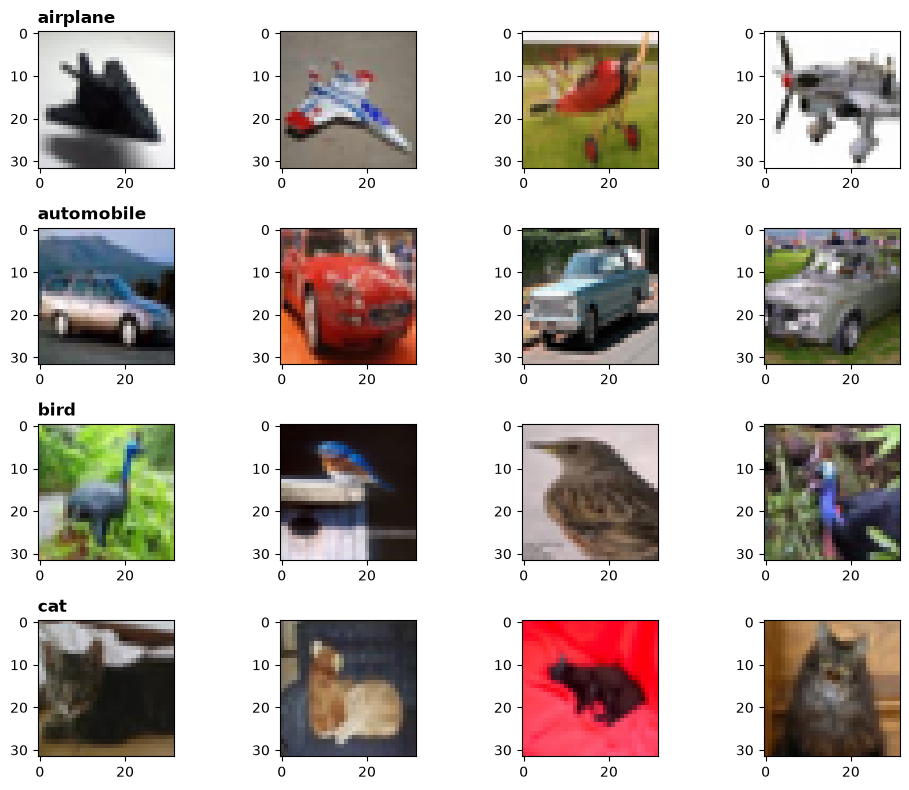

In [39]:
fig, axes = plt.subplots(len(selected_classes), 4, figsize=(10, 8))

for row, (class_id, class_name) in enumerate(selected_classes.items()):
    class_images = X_subset[y_subset == class_id][:4]
    for ax, image in zip(axes[row], class_images):
        ax.imshow(image)
    axes[row, 0].set_title(class_name, loc="left", fontweight="bold")

plt.tight_layout()
plt.show()

# Part 2 - Edge Histograms and Similarity Measurements

For each of the four classes, we select one representative image from the balanced subset. Each RGB image is converted to grayscale, processed with the assignment's Sobel-angle formula, and represented by a 36-bin edge-orientation histogram.

CIFAR-10 images all have the same 32×32 resolution. Therefore, every raw histogram contains exactly 1,024 pixel observations, making the required pixel-count histograms directly comparable without resizing or count normalization.

In [40]:
import pandas as pd
from skimage import color, exposure, filters
from sklearn.metrics import pairwise_distances


chosen_images = {} # the images chosen in this task

for class_id, class_name in selected_classes.items():
    class_images = X_subset[y_subset == class_id]
    
    first_image = class_images[0]
    
    chosen_images[class_name] = first_image

## 2(a-d). Grayscale conversion and 36-bin edge histograms

In [41]:
def angle(dx, dy):
    """Calculate the angles between horizontal and vertical operators."""
    return np.mod(np.arctan2(dy, dx), np.pi)

def edge_histogram(rgb_image, nbins=36):
    gray = color.rgb2gray(rgb_image)                                 # grayscale
    angle_sobel = angle(filters.sobel_h(gray), filters.sobel_v(gray))   # edge angle per pixel
    counts, _ = exposure.histogram(angle_sobel, nbins=nbins)       # 36-bin histogram
    return counts

edge_histograms = {name: edge_histogram(image) for name, image in chosen_images.items()}

## 2(e). Images and their edge histograms

Each row below exhibits one representative image and its edge histogram. The histogram axes use the labels required by the assignment: **Bins** and **Pixel Count**.

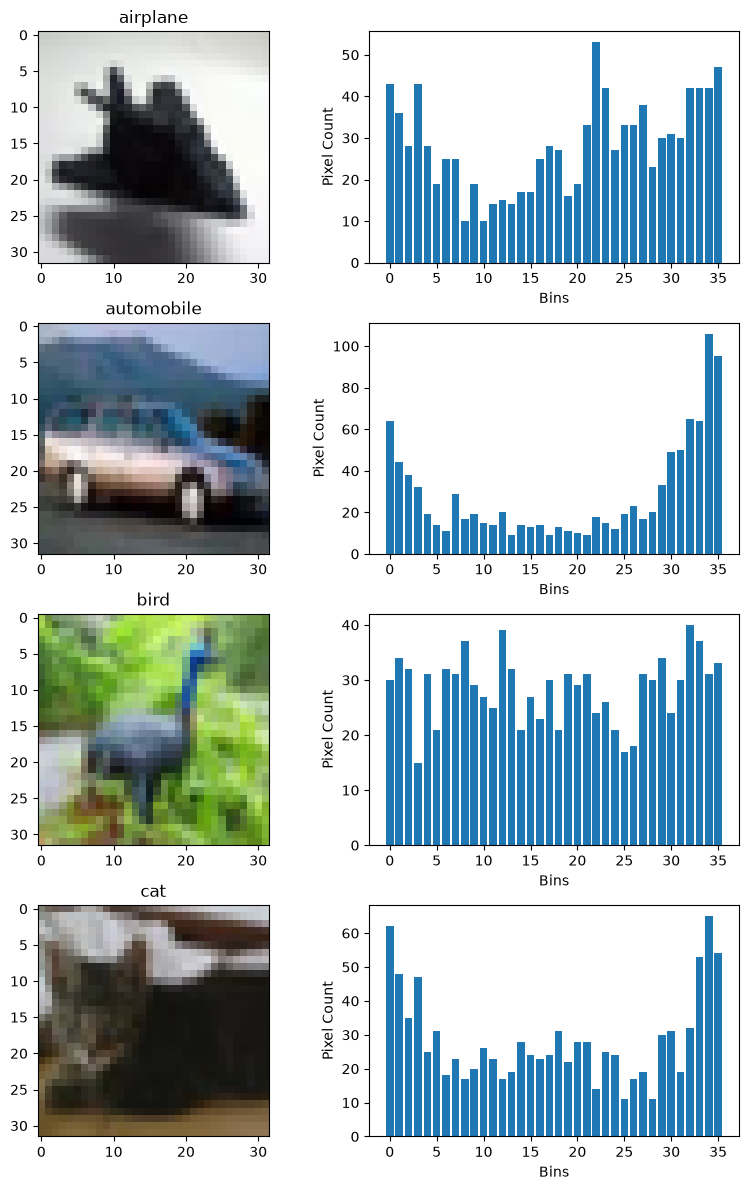

In [42]:
fig, axes = plt.subplots(len(chosen_images), 2, figsize=(8, 12))

for row, (class_name, image) in enumerate(chosen_images.items()):
    axes[row, 0].imshow(image)
    axes[row, 0].set_title(class_name)

    axes[row, 1].bar(range(36), edge_histograms[class_name])
    axes[row, 1].set_xlabel("Bins")
    axes[row, 1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

## 2(f). Histogram comparison

We compare the **airplane** and **automobile** histograms. Both classes represent transportation objects, so this pair tests whether their edge-orientation structures remain distinguishable despite a semantic relationship.
All three are distances, so a smaller value means greater similarity.

In [44]:
h1 = edge_histograms["airplane"]
h2 = edge_histograms["automobile"]

for metric in ["euclidean", "manhattan", "cosine"]:
    distance = pairwise_distances([h1], [h2], metric=metric)[0, 0]
    print(f"{metric:10s} distance: {distance:.4f}")

euclidean  distance: 116.7219
manhattan  distance: 516.0000
cosine     distance: 0.1481


# Part 3 - Histogram of Oriented Gradients (HOG)

In this case, We reuse the representative **airplane** image so its HOG representation can be compared conceptually with the global edge histogram already produced above. The grayscale image is used because the descriptor is based on intensity gradients.

In [45]:
from skimage.feature import hog

hog_image_rgb = chosen_images["airplane"]
hog_image_gray = color.rgb2gray(hog_image_rgb)

hog_descriptor, hog_visualization = hog(
    hog_image_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
)

print("HOG descriptor shape:", hog_descriptor.shape)

HOG descriptor shape: (324,)


## HOG visualization

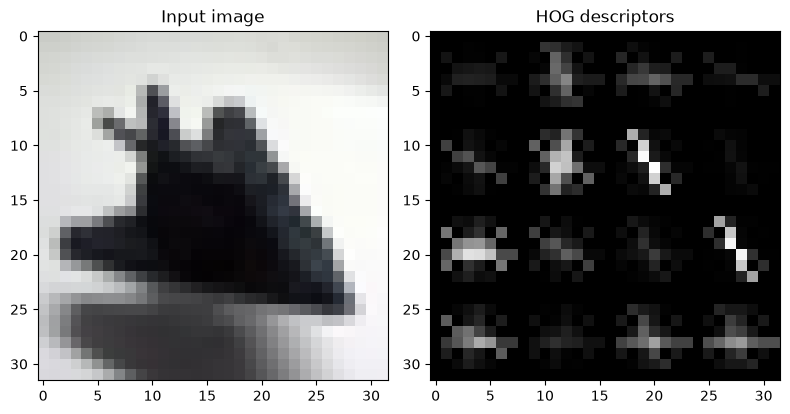

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(hog_image_rgb)
ax1.set_title("Input image")

ax2.imshow(hog_visualization, cmap="gray")
ax2.set_title("HOG descriptors")

plt.tight_layout()
plt.show()

The visualization emphasizes the airplane boundary and other strong local intensity transitions.

# Part 4 - PCA Dimensionality Reduction

## 4(a-b). Convert all images to edge histograms

Every image follows the same pipeline: RGB → grayscale → horizontal and vertical Sobel responses → unsigned angle map → 36-bin histogram.

In [47]:
X_edge_histograms = np.array([edge_histogram(image) for image in X_subset])
print("Feature matrix shape:", X_edge_histograms.shape)

Feature matrix shape: (200, 36)


## 4(c). Reduce the histograms from 36 dimensions to 2

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_edge_histograms)      # It is worth noting that class labels are not used here

print("Reduced shape:", X_pca_2d.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(4))

Reduced shape: (200, 2)
Explained variance ratio: [0.4287 0.18  ]


## 4(d). Plot the four classes in PCA space

Each point represents one image. 

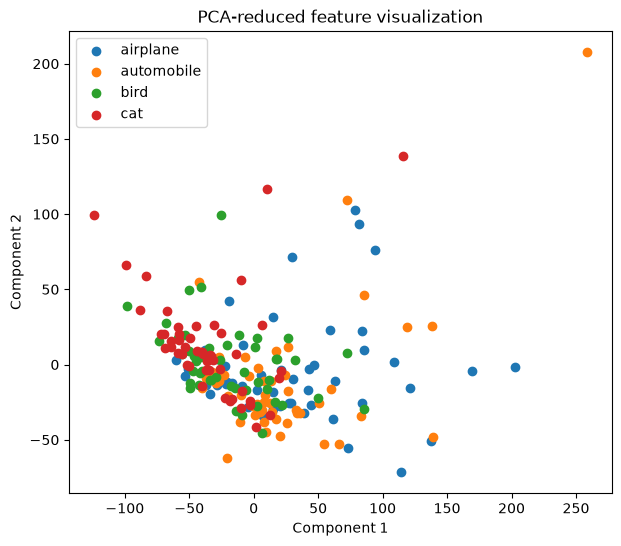

In [49]:
# cell 33  4(d) scatter plot, one color per class
fig, ax = plt.subplots(figsize=(7, 6))

for class_id, class_name in selected_classes.items():
    points = X_pca_2d[y_subset == class_id]
    ax.scatter(points[:, 0], points[:, 1], label=class_name)

ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_title("PCA-reduced feature visualization")
ax.legend()
plt.show()

### Conclusion

The first two principal components retain **42.87%** + **18.00%** = **62.87%** of the variance in the 36-bin edge histograms. In the scatter plot, all four colored point clouds overlap in the central region. 
**Therefore, 0 of the 4 classes are visually separable (non-overlapping) in this two-dimensional PCA plot.** This result suggests that a global edge-orientation histogram alone does not preserve enough spatial or semantic information to clearly distinguish these four CIFAR-10 classes.

# Final Problem - Tweet Text Processing and PCA

The assigned `student_3` dataset contains separate training, validation, and test files. Following the assignment, this section uses **only `student_3/train.json`**. 

This dataset is actually a kind of **multi-label** data: a tweet may have several emotion fields set to `true`.

In [50]:
tweets = pd.read_json("student_3/train.json", lines=True)
print("Training records:", len(tweets))

Training records: 3000


In [51]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

X_counts = CountVectorizer().fit_transform(tweets["Tweet"])
X_tfidf = TfidfVectorizer().fit_transform(tweets["Tweet"])

print("Token count matrix:", X_counts.shape)
print("TF-IDF matrix:     ", X_tfidf.shape)

Token count matrix: (3000, 9588)
TF-IDF matrix:      (3000, 9588)


In [52]:
selected_text_classes = ["anger", "fear", "joy", "sadness"]

labels = tweets[selected_text_classes]
single_label = (labels.sum(axis=1) == 1).to_numpy()
tweet_class = labels[single_label].idxmax(axis=1).to_numpy()

print("Tweets used:", single_label.sum())

Tweets used: 1880


It is worth noting that here we only look at the four selected emotion columns and keep a tweet if **exactly one** of them is `true`. 

In [53]:
counts_2d = PCA(n_components=2, random_state=0).fit_transform(X_counts[single_label].toarray())
tfidf_2d = PCA(n_components=2, random_state=0).fit_transform(X_tfidf[single_label].toarray())

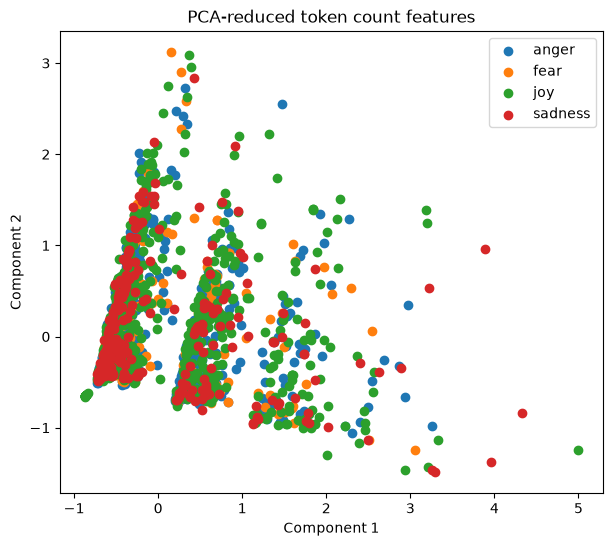

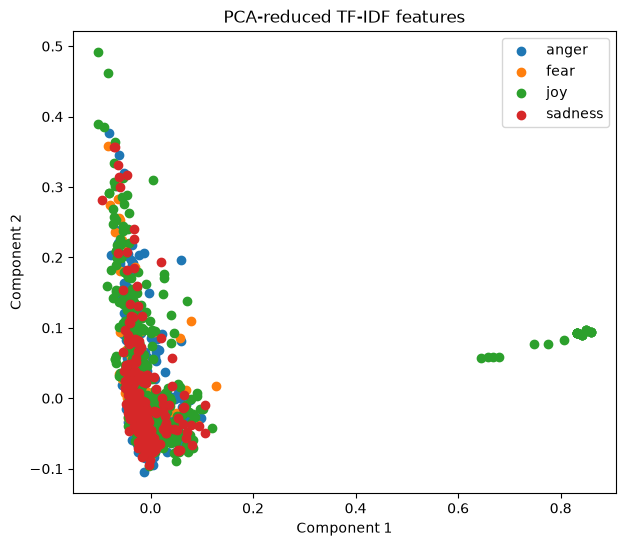

In [54]:
for name, points in [("token count", counts_2d), ("TF-IDF", tfidf_2d)]:
    fig, ax = plt.subplots(figsize=(7, 6))
    for class_name in text_classes:
        class_points = points[tweet_class == class_name]
        ax.scatter(class_points[:, 0], class_points[:, 1], label=class_name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_title(f"PCA-reduced {name} features")
    ax.legend()
    plt.show()

## Final conclusion

Using the default parameters, both `CountVectorizer` and `TfidfVectorizer` produce a **3,000 × 9,588** document-feature matrix. The two principal components retain **6.65%** of the variance for token counts and **1.76%** for TF-IDF, so each plot shows only a small part of the original information.

In the token-count plot, all four colors are mixed throughout the dense vertical bands. In the TF-IDF plot, the four classes
again overlap in one dense cloud near the origin.

**Therefore, none of the four selected classes are visually separable (non-overlapping) in either plot.** The low retained variance also shows that two linear components capture only a small portion of these high-dimensional text representations.